# IS 477 Project Code

In [29]:
# main
import pandas as pd
import numpy as np
import re

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dfCrashes = pd.read_csv("data/raw/crashes.csv")
dfPeople = pd.read_csv("data/raw/people.csv")

/tmp/ipykernel_10793/896320708.py:2: DtypeWarning: Columns (0: vehicle_id, 1: age, 2: bac_result, 3: cell_phone_use, 4: bac_result_value) have mixed types. Specify dtype option on import or set low_memory=False.
  dfPeople = pd.read_csv("data/raw/people.csv")


## Data Cleaning - Ganga

In [3]:
print("Our crashes dataset has", dfCrashes.shape[1], "columns and", dfCrashes.shape[0], "rows.")
print("Our people dataset has", dfPeople.shape[1], "columns and", dfPeople.shape[0], "rows.")

Our crashes dataset has 20 columns and 1041273 rows.
Our people dataset has 16 columns and 2285353 rows.


In [4]:
dfMain = dfCrashes.merge(dfPeople, left_on = "crash_record_id", right_on = "crash_record_id")

In [5]:
dfMain.head()

,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,weather_condition,lighting_condition,roadway_surface_cond,road_defect,crash_type,damage,...,safety_equipment,airbag_deployed,ejection,injury_classification,driver_action,driver_vision,physical_condition,bac_result,cell_phone_use,bac_result_value
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,2020-11-16T13:50:00.000,35,NO CONTROLS,CLEAR,DAYLIGHT,DRY,UNKNOWN,NO INJURY / DRIVE AWAY,"$501 - $1,500",...,SAFETY BELT USED,DID NOT DEPLOY,NONE,NO INDICATION OF INJURY,IMPROPER PARKING,UNKNOWN,NORMAL,TEST NOT OFFERED,NaN,NaN
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2016-04-16T05:49:00.000,30,TRAFFIC SIGNAL,CLEAR,DAWN,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"OVER $1,500",...,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,NONE,NO INDICATION OF INJURY,IMPROPER LANE CHANGE,UNKNOWN,UNKNOWN,TEST NOT OFFERED,NaN,NaN
2,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2016-04-16T05:49:00.000,30,TRAFFIC SIGNAL,CLEAR,DAWN,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"OVER $1,500",...,SAFETY BELT USED,DID NOT DEPLOY,NONE,NO INDICATION OF INJURY,NONE,NOT OBSCURED,NORMAL,TEST NOT OFFERED,NaN,NaN
3,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,2019-12-22T02:11:00.000,30,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",...,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN,TEST NOT OFFERED,NaN,NaN
4,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,2024-02-02T09:48:00.000,30,NO CONTROLS,CLEAR,DAYLIGHT,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"OVER $1,500",...,USAGE UNKNOWN,NOT APPLICABLE,NONE,NO INDICATION OF INJURY,EMERGENCY VEHICLE ON CALL,NOT OBSCURED,NORMAL,TEST NOT OFFERED,NaN,NaN


In [6]:
# general overview of dataset columns and corresponding data types
dfMain.info()

<class 'pandas.DataFrame'>
RangeIndex: 2285353 entries, 0 to 2285352
Data columns (total 35 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   crash_record_id          str    
 1   crash_date               str    
 2   posted_speed_limit       int64  
 3   traffic_control_device   str    
 4   weather_condition        str    
 5   lighting_condition       str    
 6   roadway_surface_cond     str    
 7   road_defect              str    
 8   crash_type               str    
 9   damage                   str    
 10  prim_contributory_cause  str    
 11  num_units                int64  
 12  injuries_total           float64
 13  injuries_fatal           float64
 14  injuries_incapacitating  float64
 15  crash_hour               int64  
 16  crash_day_of_week        int64  
 17  crash_month              int64  
 18  latitude                 float64
 19  longitude                float64
 20  person_id                str    
 21  person_type        

We notice [...]

In [7]:
# Convert crash_date to datetime
dfMain['crash_date'] = pd.to_datetime(dfMain['crash_date'])

# convert age to numeric
#dfMain['age'] = pd.to_numeric(dfMain['age'], errors='coerce')

In [8]:
# calculate the percentage of missing values per column
missing = (dfMain.isna().sum() / len(dfMain) * 100).round(2)

# highlight columns with missing values, sorted from most to least missing
print(missing[missing > 0].sort_values(ascending = False))

bac_result_value         99.93
cell_phone_use           99.91
age                      24.00
driver_action            20.31
bac_result               20.21
driver_vision            19.54
physical_condition       19.46
injury_classification     3.96
sex                       2.88
airbag_deployed           2.69
vehicle_id                2.08
ejection                  1.98
latitude                  0.76
longitude                 0.76
safety_equipment          0.48
dtype: float64


In [9]:
# cell_phone_use and bac_result_value have extremely low non-null counts, so we check their values
print(dfMain['cell_phone_use'].value_counts(dropna=False))
print(dfMain['bac_result_value'].value_counts(dropna=False))

cell_phone_use
NaN     2283365
Y           318
N           155
0.0         116
0.17         88
         ...   
0.68          1
0.47          1
0.8           1
0.44          1
0.95          1
Name: count, Length: 89, dtype: int64
bac_result_value
NaN     2283695
Y           436
N           253
0.0          47
0            36
         ...   
0.6           1
0.05          1
0.01          1
0.35          1
0.85          1
Name: count, Length: 88, dtype: int64


In [10]:
# age is stored as object dtype instead of numeric, so we inspect its values to see which non-numeric entries exist before converting
print(dfMain['age'].value_counts(dropna=False).head(20))

age
NaN                 548438
USAGE UNKNOWN       169937
SAFETY BELT USED    158286
27.0                 34345
25.0                 34294
26.0                 33806
28.0                 33784
24.0                 33106
29.0                 32995
30.0                 31512
23.0                 31475
31.0                 30631
32.0                 29738
33.0                 28629
22.0                 28528
34.0                 26976
35.0                 26431
21.0                 26054
36.0                 25728
37.0                 24783
Name: count, dtype: int64


In [11]:
# check the range of age after coercing to numeric to identify any unrealistic values that may be data entry errors
print(dfMain['age'].describe())

count           1736915
unique              250
top       USAGE UNKNOWN
freq             169937
Name: age, dtype: object


In [12]:
# bac_result is object dtype so we check its values to see whether it is categorical, numeric, or a mix of both
print(dfMain['bac_result'].value_counts(dropna=False).head(10))

bac_result
TEST NOT OFFERED                   1560330
NaN                                 461839
NONE                                 91638
TEST REFUSED                         16007
UNKNOWN                               6607
TEST PERFORMED, RESULTS UNKNOWN       3611
TEST TAKEN                            2797
26                                    2726
27                                    2643
25                                    2622
Name: count, dtype: int64


In [13]:
# driver_action, driver_vision, and physical_condition have ~20% missing values, so we check if those missing rows correspond to non-driver person types which would mean the missing values are expected and not a data quality issue
drivers_only = dfMain[['driver_action', 'driver_vision', 'physical_condition']].isna().all(axis=1).sum()
print(f"Rows missing all driver columns: {drivers_only}")
print(dfMain['person_type'].value_counts())

Rows missing all driver columns: 442197
person_type
DRIVER                 1777875
PASSENGER               460076
PEDESTRIAN               27483
BICYCLE                  17555
NON-MOTOR VEHICLE         1996
NON-CONTACT VEHICLE        368
Name: count, dtype: int64


In [14]:
# drop cell_phone_use and bac_result_value since both are over 99% missing
dfMain = dfMain.drop(columns=['cell_phone_use', 'bac_result_value'])

In [15]:
# convert crash_date from string to datetime
# so we can extract time-based features and do date arithmetic later
dfMain['crash_date'] = pd.to_datetime(dfMain['crash_date'])

In [16]:
# convert age to numeric — non-numeric strings like 'USAGE UNKNOWN' and
# 'SAFETY BELT USED' were found in this column due to a data source issue
# errors='coerce' turns those into NaN instead of raising an error
dfMain['age'] = pd.to_numeric(dfMain['age'], errors='coerce')

# cap age at 120 — values above 120 are almost certainly data entry errors
# values between 100-120 are retained as they are rare but plausible
dfMain['age'] = dfMain['age'].where(dfMain['age'].between(0, 120))

In [17]:
# bac_result contains a mix of categorical labels and raw numeric BAC values. numeric entries are consolidated into 'TEST TAKEN' since the actual values were too sparse to analyze separately after bac_result_value was dropped
def clean_bac(val):
    if pd.isna(val):
        return val
    if re.match(r'^\d+\.?\d*$', str(val)):  # if the value is purely numeric
        return 'TEST TAKEN'
    return val

dfMain['bac_result'] = dfMain['bac_result'].apply(clean_bac)

# keep only known valid BAC categories and convert everything else to NaN
valid_bac = ['TEST NOT OFFERED', 'NONE', 'TEST REFUSED', 'UNKNOWN',
             'TEST PERFORMED, RESULTS UNKNOWN', 'TEST TAKEN']

dfMain['bac_result'] = dfMain['bac_result'].where(
    dfMain['bac_result'].isin(valid_bac), other=None
)

In [18]:
# convert columns with a fixed set of repeated string values to category dtype to reduce memory usage and make groupby and value_counts operations faster
cat_columns = ['traffic_control_device', 'weather_condition', 'lighting_condition',
               'roadway_surface_cond', 'road_defect', 'crash_type', 'damage',
               'prim_contributory_cause', 'person_type', 'sex', 'safety_equipment',
               'airbag_deployed', 'ejection', 'injury_classification', 'driver_action',
               'driver_vision', 'physical_condition', 'bac_result']

dfMain[cat_columns] = dfMain[cat_columns].astype('category')

In [19]:
# final check
dfMain.info()

<class 'pandas.DataFrame'>
RangeIndex: 2285353 entries, 0 to 2285352
Data columns (total 33 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   crash_record_id          str           
 1   crash_date               datetime64[us]
 2   posted_speed_limit       int64         
 3   traffic_control_device   category      
 4   weather_condition        category      
 5   lighting_condition       category      
 6   roadway_surface_cond     category      
 7   road_defect              category      
 8   crash_type               category      
 9   damage                   category      
 10  prim_contributory_cause  category      
 11  num_units                int64         
 12  injuries_total           float64       
 13  injuries_fatal           float64       
 14  injuries_incapacitating  float64       
 15  crash_hour               int64         
 16  crash_day_of_week        int64         
 17  crash_month              int64        

## Exploratory Data Analysis - Ganga

We decided to complete EDA using a smaller random sample of the data for quicker computing.

In [24]:
sample = dfMain.sample(frac = 0.1, random_state = 42)

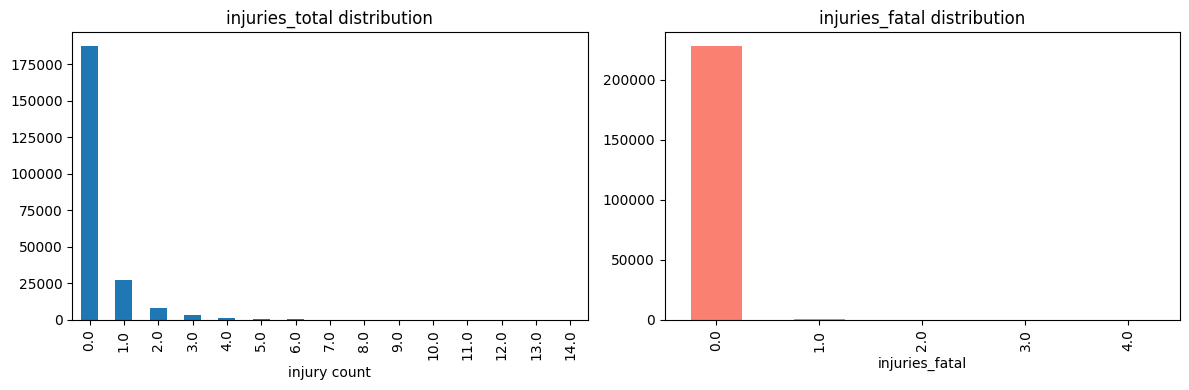

       injuries_total  injuries_fatal
count   228535.000000   228535.000000
mean         0.289002        0.001575
std          0.801474        0.044049
min          0.000000        0.000000
25%          0.000000        0.000000
50%          0.000000        0.000000
75%          0.000000        0.000000
max         21.000000        4.000000

Zero-injury crashes: 82.0%
Fatal crashes: 0.1%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample['injuries_total'].value_counts().sort_index().head(15).plot(kind='bar', ax=axes[0])
axes[0].set_title('injuries_total distribution')
axes[0].set_xlabel('injury count')

sample['injuries_fatal'].value_counts().sort_index().head(10).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('injuries_fatal distribution')

plt.tight_layout()
plt.show()

print(sample[['injuries_total','injuries_fatal']].describe())
print(f"\nZero-injury crashes: {(sample['injuries_total'] == 0).mean():.1%}")
print(f"Fatal crashes: {(sample['injuries_fatal'] > 0).mean():.1%}")


weather_condition — 12 categories, 7 rare (<1%)
weather_condition
CLEAR                    0.793104
RAIN                     0.086438
UNKNOWN                  0.048150
SNOW                     0.032485
CLOUDY/OVERCAST          0.030971
OTHER                    0.003194
FREEZING RAIN/DRIZZLE    0.002354
FOG/SMOKE/HAZE           0.001483

lighting_condition — 6 categories, 0 rare (<1%)
lighting_condition
DAYLIGHT                  0.654591
DARKNESS, LIGHTED ROAD    0.220154
DARKNESS                  0.043468
UNKNOWN                   0.036336
DUSK                      0.029772
DAWN                      0.015678

roadway_surface_cond — 7 categories, 3 rare (<1%)
roadway_surface_cond
DRY                0.742438
WET                0.131717
UNKNOWN            0.084477
SNOW OR SLUSH      0.031474
ICE                0.007137
OTHER              0.002472
SAND, MUD, DIRT    0.000284

road_defect — 7 categories, 5 rare (<1%)
road_defect
NO DEFECTS           0.789083
UNKNOWN              0.194675
O

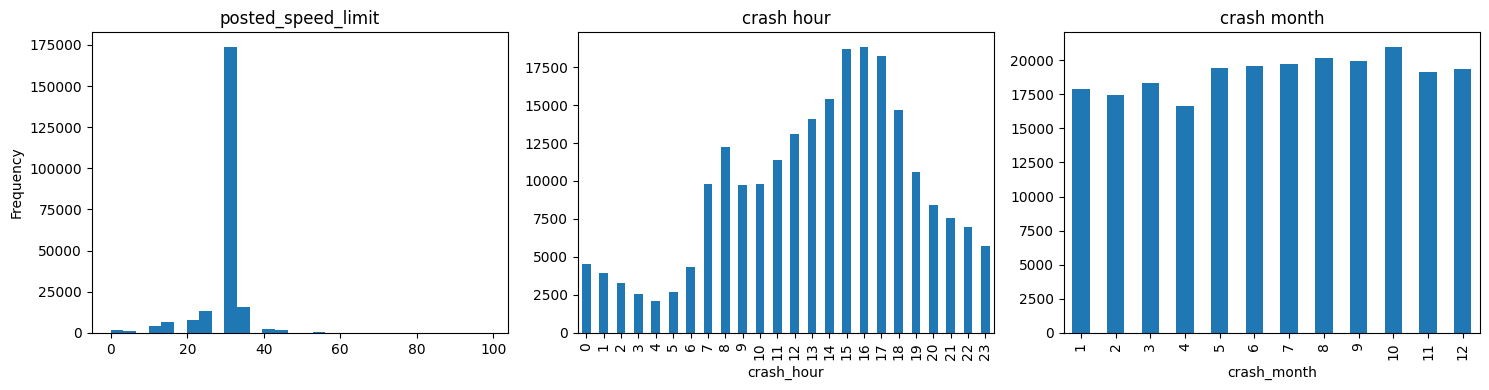

In [26]:
cat_cols = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond',
    'road_defect', 'crash_type', 'damage', 'prim_contributory_cause',
    'traffic_control_device'
]

for col in cat_cols:
    counts = sample[col].value_counts(normalize=True)
    rare = counts[counts < 0.01]
    print(f"\n{col} — {counts.shape[0]} categories, {len(rare)} rare (<1%)")
    print(counts.head(8).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample['posted_speed_limit'].plot(kind='hist', bins=30, ax=axes[0])
axes[0].set_title('posted_speed_limit')

sample['crash_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('crash hour')

sample['crash_month'].value_counts().sort_index().plot(kind='bar', ax=axes[2])
axes[2].set_title('crash month')

plt.tight_layout()
plt.show()


Mean injuries_total by weather_condition:
weather_condition
SLEET/HAIL                  0.418251
OTHER                       0.364384
FOG/SMOKE/HAZE              0.348083
BLOWING SNOW                0.342105
RAIN                        0.332034
SEVERE CROSS WIND GATE      0.305556
CLEAR                       0.296797
FREEZING RAIN/DRIZZLE       0.289963
CLOUDY/OVERCAST             0.276208
SNOW                        0.254041
UNKNOWN                     0.104689
BLOWING SAND, SOIL, DIRT    0.000000

Mean injuries_total by lighting_condition:
lighting_condition
DARKNESS, LIGHTED ROAD    0.386083
DAWN                      0.324309
DUSK                      0.300412
DARKNESS                  0.290517
DAYLIGHT                  0.265821
UNKNOWN                   0.092004

Mean injuries_total by road_defect:
road_defect
DEBRIS ON ROADWAY    0.707006
WORN SURFACE         0.424870
SHOULDER DEFECT      0.390501
OTHER                0.313029
NO DEFECTS           0.298947
UNKNOWN              0.

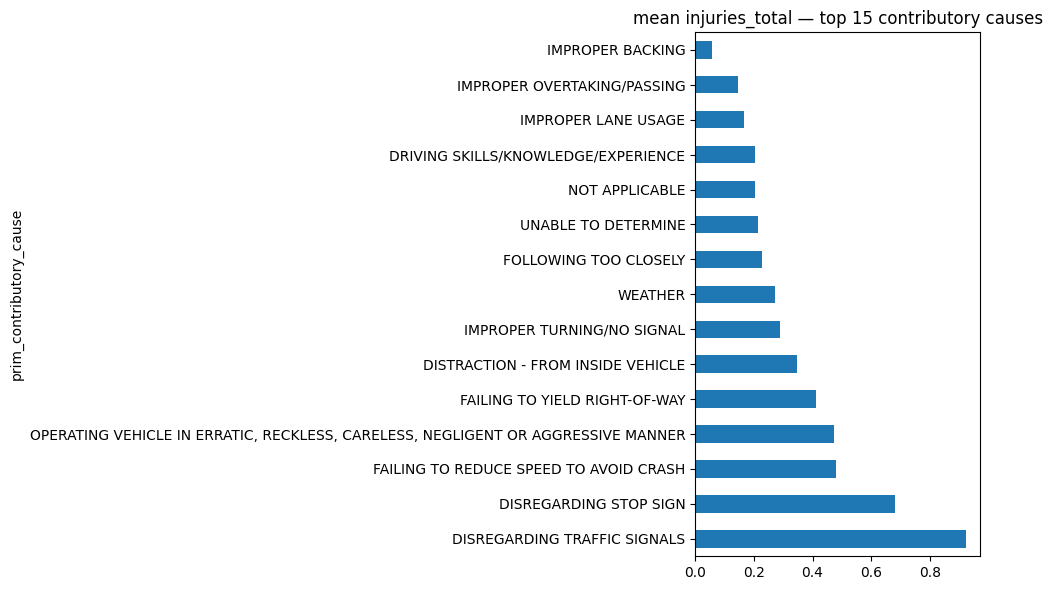

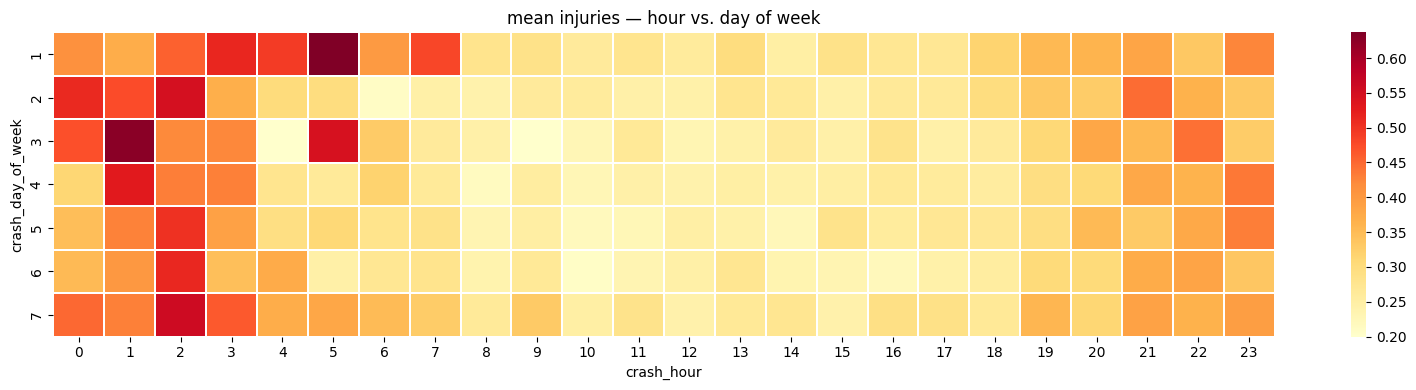

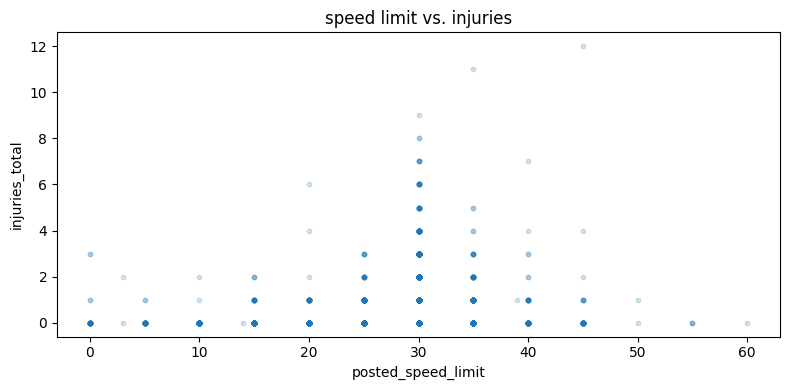

In [30]:
# mean injuries by key categoricals
for col in ['weather_condition', 'lighting_condition', 'road_defect', 'roadway_surface_cond']:
    means = sample.groupby(col)['injuries_total'].mean().sort_values(ascending=False)
    print(f"\nMean injuries_total by {col}:\n{means.to_string()}")

# prim_contributory_cause — top 15 only
top_causes = sample['prim_contributory_cause'].value_counts().head(15).index
cause_means = (
    sample[sample['prim_contributory_cause'].isin(top_causes)]
    .groupby('prim_contributory_cause')['injuries_total']
    .mean()
    .sort_values(ascending=False)
)
cause_means.plot(kind='barh', figsize=(10, 6))
plt.title('mean injuries_total — top 15 contributory causes')
plt.tight_layout()
plt.show()

# crash hour × day_of_week heatmap
pivot = sample.pivot_table(
    values='injuries_total',
    index='crash_day_of_week',
    columns='crash_hour',
    aggfunc='mean'
)
plt.figure(figsize=(16, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('mean injuries — hour vs. day of week')
plt.tight_layout()
plt.show()

# speed limit scatter (sampled further to avoid overplotting)
mini = sample.sample(5000, random_state=1)
plt.figure(figsize=(8, 4))
plt.scatter(mini['posted_speed_limit'], mini['injuries_total'], alpha=0.2, s=10)
plt.xlabel('posted_speed_limit')
plt.ylabel('injuries_total')
plt.title('speed limit vs. injuries')
plt.tight_layout()
plt.show()

In [31]:
# null rates
null_rates = sample.isnull().mean().sort_values(ascending=False)
print("Null rates:\n", null_rates[null_rates > 0].to_string())

# speed limit anomalies
print("\nSpeed limit value counts (suspicious values):")
print(sample['posted_speed_limit'].value_counts().sort_index().to_string())

# injury outliers
print("\nHigh injury crashes (injuries_total > 10):")
print(sample[sample['injuries_total'] > 10][['crash_record_id','injuries_total','injuries_fatal','prim_contributory_cause']].head(20))

# duplicate IDs
dup_count = sample['crash_record_id'].duplicated().sum()
print(f"\nDuplicate crash_record_ids in sample: {dup_count}")

# BAC and physical_condition coverage (person-level join cols)
for col in ['bac_result', 'physical_condition']:
    missing = sample[col].isna().mean() if col in sample.columns else 'not in df'
    print(f"{col} missing: {missing}")

Null rates:
 age                      0.413797
driver_action            0.202835
bac_result               0.202188
driver_vision            0.194898
physical_condition       0.194242
injury_classification    0.040138
sex                      0.028551
airbag_deployed          0.026228
vehicle_id               0.019809
ejection                 0.019371
longitude                0.007552
latitude                 0.007552
safety_equipment         0.004376

Speed limit value counts (suspicious values):
posted_speed_limit
0       1497
1          8
2          5
3         52
5        918
7          1
9         14
10      4167
11         1
14         2
15      6295
20      7967
24         3
25     13513
26         4
29         1
30    173983
32         7
33         2
34         8
35     15521
36         3
38         1
39        22
40      2493
45      1689
50        75
55       248
60        18
65         3
70         1
99        13

High injury crashes (injuries_total > 10):
                   